## Trial-level verifier metrics

Per-trial decoder accuracy + dataset-scale stats pulled from `harbor-jobs/<ds>/<agent>/<trial>/verifier/metrics.json`. The pull script is `eval/pull_trial_metrics.py`; loaders live in `utils.py` (`load_trial_metrics`, `trial_metrics_df`).

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle as _Rect

# Where LaTeX table dumps land (one .tex per table for inclusion via \input).
FIGURES_DIR = Path(__file__).resolve().parents[2] / "figures"


def _emit_latex(text: str, filename: str) -> str:
    """Print to stdout AND write to figures/<filename>; return the text."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    (FIGURES_DIR / filename).write_text(text + "\n")
    print(text)
    return text

%load_ext autoreload
%autoreload 2

import seaborn as sns
sns.set_theme(style="ticks", rc={"axes.spines.right": False, "axes.spines.top": False})
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from utils import load_trial_metrics, trial_metrics_df

mdf = trial_metrics_df(load_trial_metrics())

# Display-name mirror of analysis.ipynb's cell 9fc5189e
DISPLAY_NAME = {"allen2p": "Allen2P", "zhang2025": "Zhang2025 (IBL)"}
def display_name(ds):
    return DISPLAY_NAME.get(ds, ds[:1].upper() + ds[1:])

SUPERVISED_DS   = ["allen2p", "lee2025", "majnik2025", "sosa2024"]
UNSUPERVISED_DS = ["chen2024", "hasnain2024", "zhang2025", "zhong2025"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# helpers

def _truthy(row, key):
    v = row.get(key)
    return bool(v) if v is not None and not (isinstance(v, float) and np.isnan(v)) else False

def _present(row, key):
    v = row.get(key)
    return v is not None and not (isinstance(v, float) and np.isnan(v))

def _below(row, key, thresh):
    v = row.get(key)
    return _present(row, key) and v < thresh

def _empty_list(row, key):
    v = row.get(key)
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None        # field never recorded for this trial → NA
    try:
        return len(v) == 0
    except TypeError:
        return None

def _eq(row, key, target):
    v = row.get(key)
    if v is None or target is None or (isinstance(v, float) and np.isnan(v)):
        return None
    return v == target

def _check_values(ds, fn):
    """6-array of bool/None for one (dataset, check)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    out = np.full(6, np.nan)            # NaN = NA / not applicable
    for i, (_, row) in enumerate(sub.iterrows()):
        res = fn(row)
        if res is None:
            continue                    # leave NaN
        out[i] = 1.0 if res else 0.0
    return out


def _raw_values(ds, fn):
    """6-array of raw numeric values (or NaN) for one (dataset, getter).
    Like `_check_values` but does not coerce to bool — for rows that display
    counts (e.g. dinput, doutput, total n_classes)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    out = np.full(6, np.nan)
    for i, (_, row) in enumerate(sub.iterrows()):
        if i >= 6:
            break
        v = fn(row)
        if v is None:
            continue
        if isinstance(v, float) and np.isnan(v):
            continue
        try:
            out[i] = float(v)
        except (TypeError, ValueError):
            continue
    return out

def _trial_values(ds, ratio_col, raw_col):
    """6-array of per-trial values + is_ratio flag (claude×3 then codex×3)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    if ratio_col and ratio_col in sub.columns and not sub[ratio_col].isna().all():
        return sub[ratio_col].values.astype(float), True
    if raw_col and raw_col in sub.columns and not sub[raw_col].isna().all():
        return sub[raw_col].values.astype(float), False
    return np.full(6, np.nan), False

def _output_variables_match(r):
    if not _present(r, "output_fraction_mean_cost"):
        return None
    return _below(r, "output_fraction_mean_cost", 1.0)

def _output_ranges_match(r):
    if not _output_variables_match(r):
        return None
    if not _present(r, "output_range_error_max"):
        return None
    return _eq(r, "output_range_error_max", 0)

def _total_n_output_classes(row):
    """Sum of `output_nclasses_<var>` across all output variables for a row.
    Returns None when no per-variable n_classes field is recorded."""
    total = 0
    found = False
    for k, v in row.items():
        if not (isinstance(k, str)
                and k.startswith("output_nclasses_")
                and not k.startswith("output_nclasses_reference_")):
            continue
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        total += int(v)
        found = True
    return total if found else None

def _fmt(v, is_ratio):
    if np.isnan(v):
        return ""
    if is_ratio:
        return f"{v:.2f}"
    if v >= 1000: return f"{v:,.0f}"
    if v >= 100:  return f"{v:.0f}"
    if v >= 10:   return f"{v:.1f}"
    return f"{v:.2f}"



### Per-dataset metric table (figure)

Two figures (supervised / unsupervised). Layout mirrors the rating-square summary from `analysis.ipynb`: rows = metric, columns = dataset, each cell is a 6-square strip (3 claude-code + 3 codex). Supervised cells are coloured by ratio (RdYlGn centred at 1.0); unsupervised cells are flat grey raw values. Decoder section breaks out one row per decoded variable; variables differ per dataset, so shorter columns leave bottom slots empty.

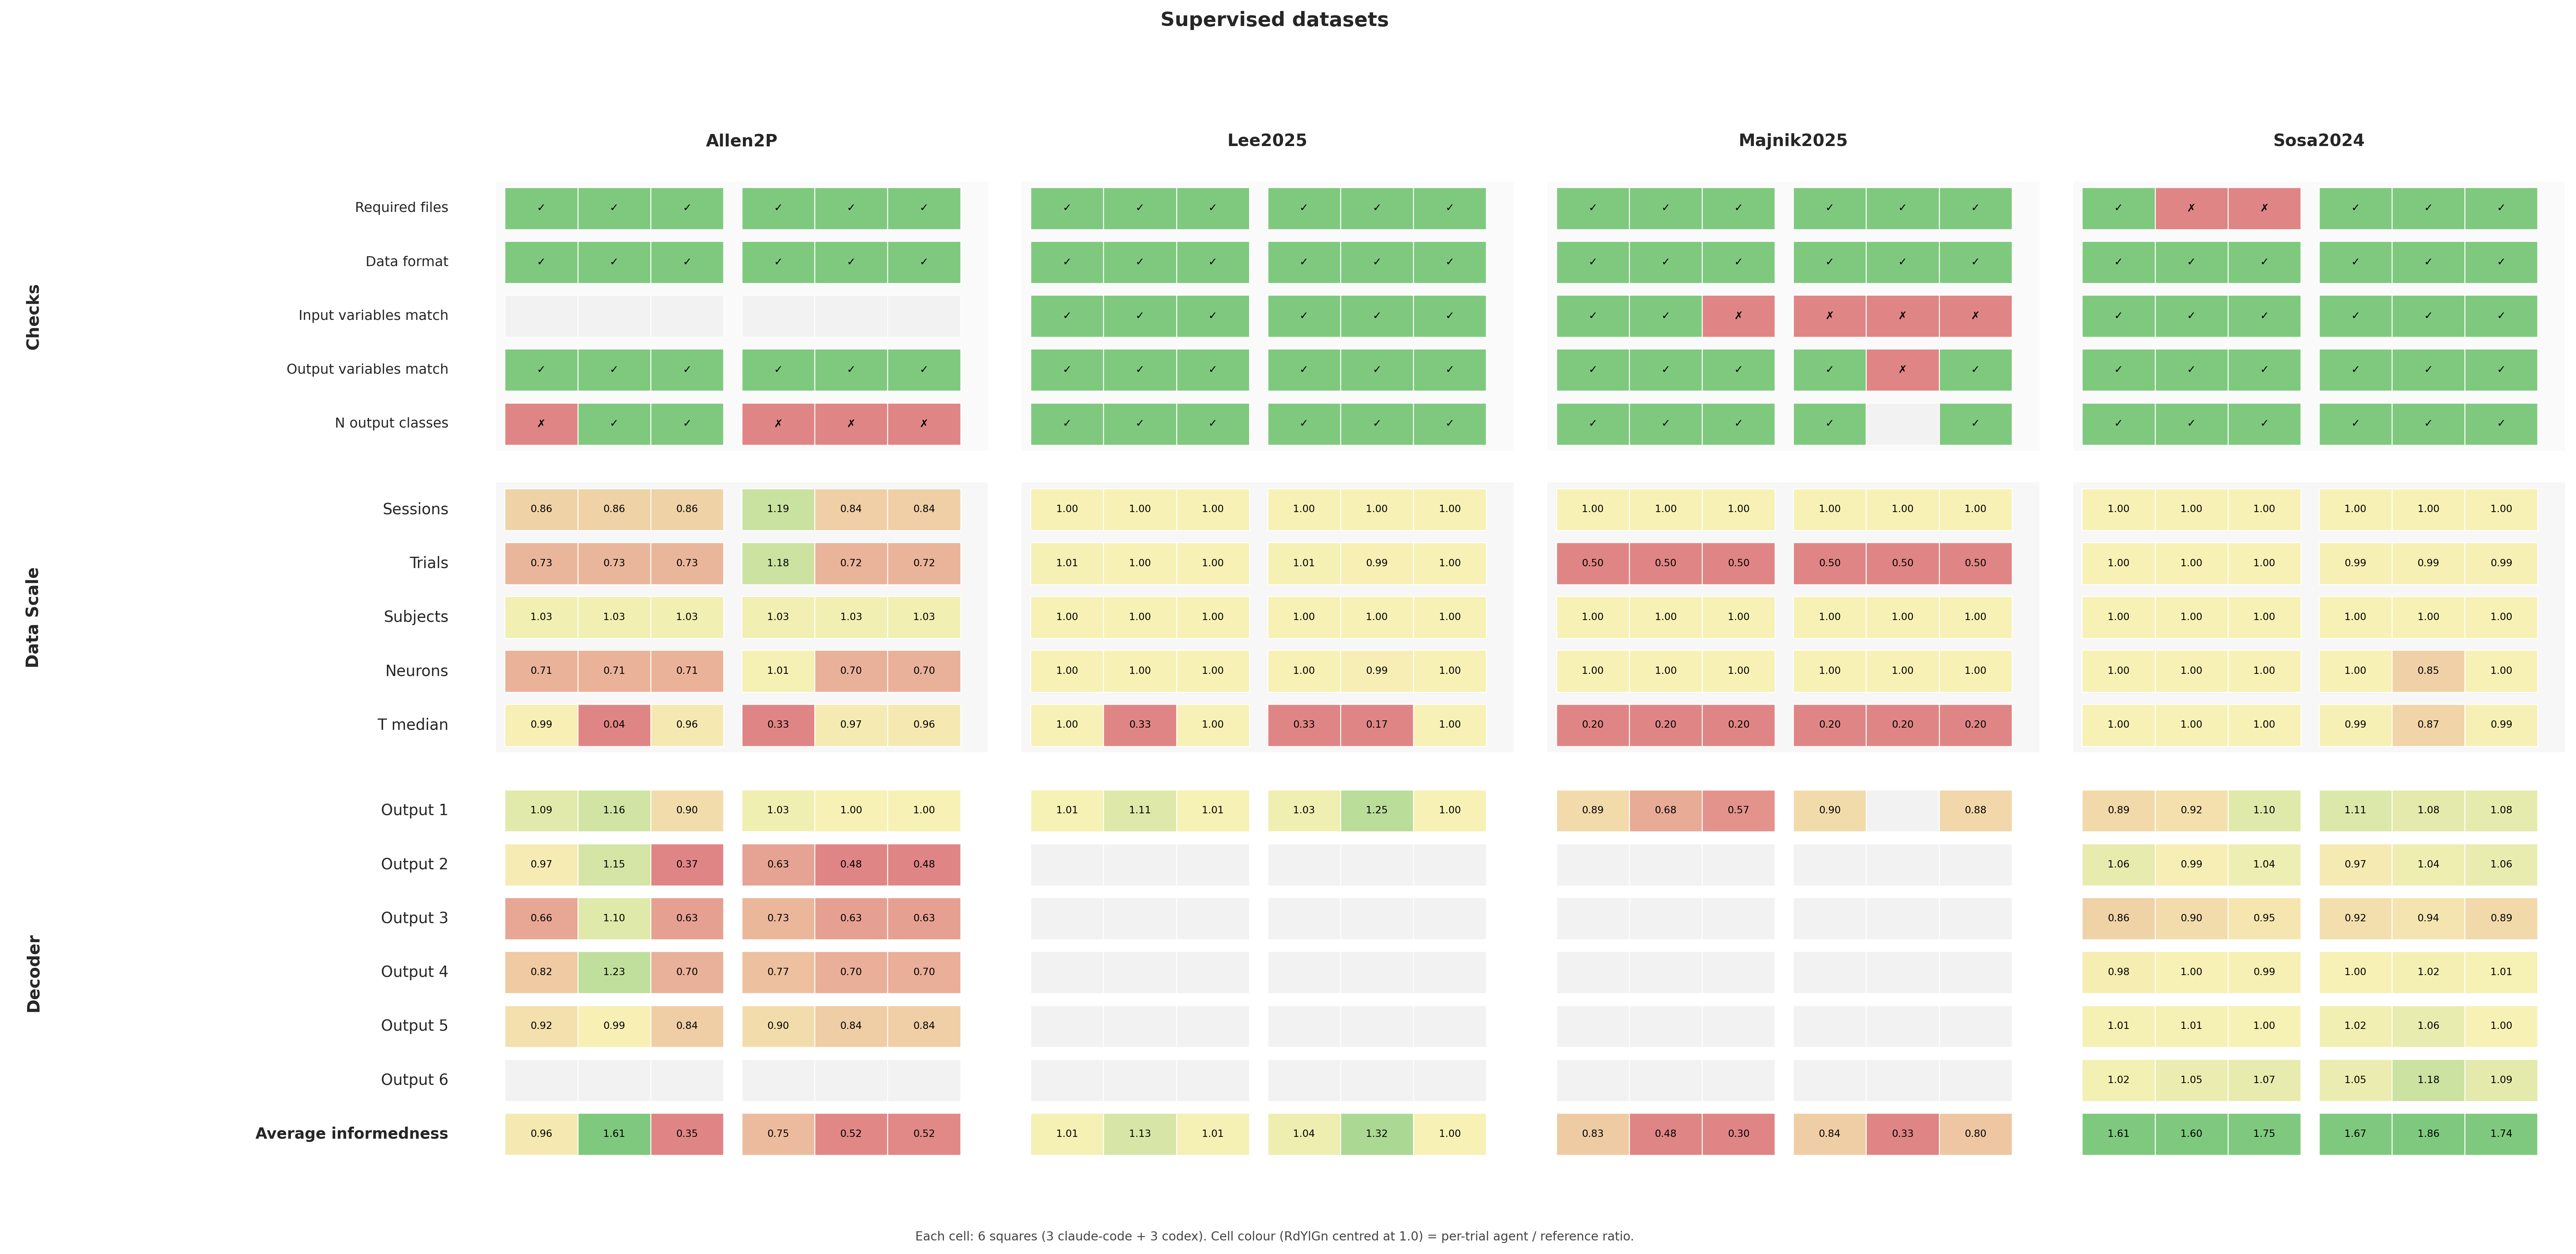

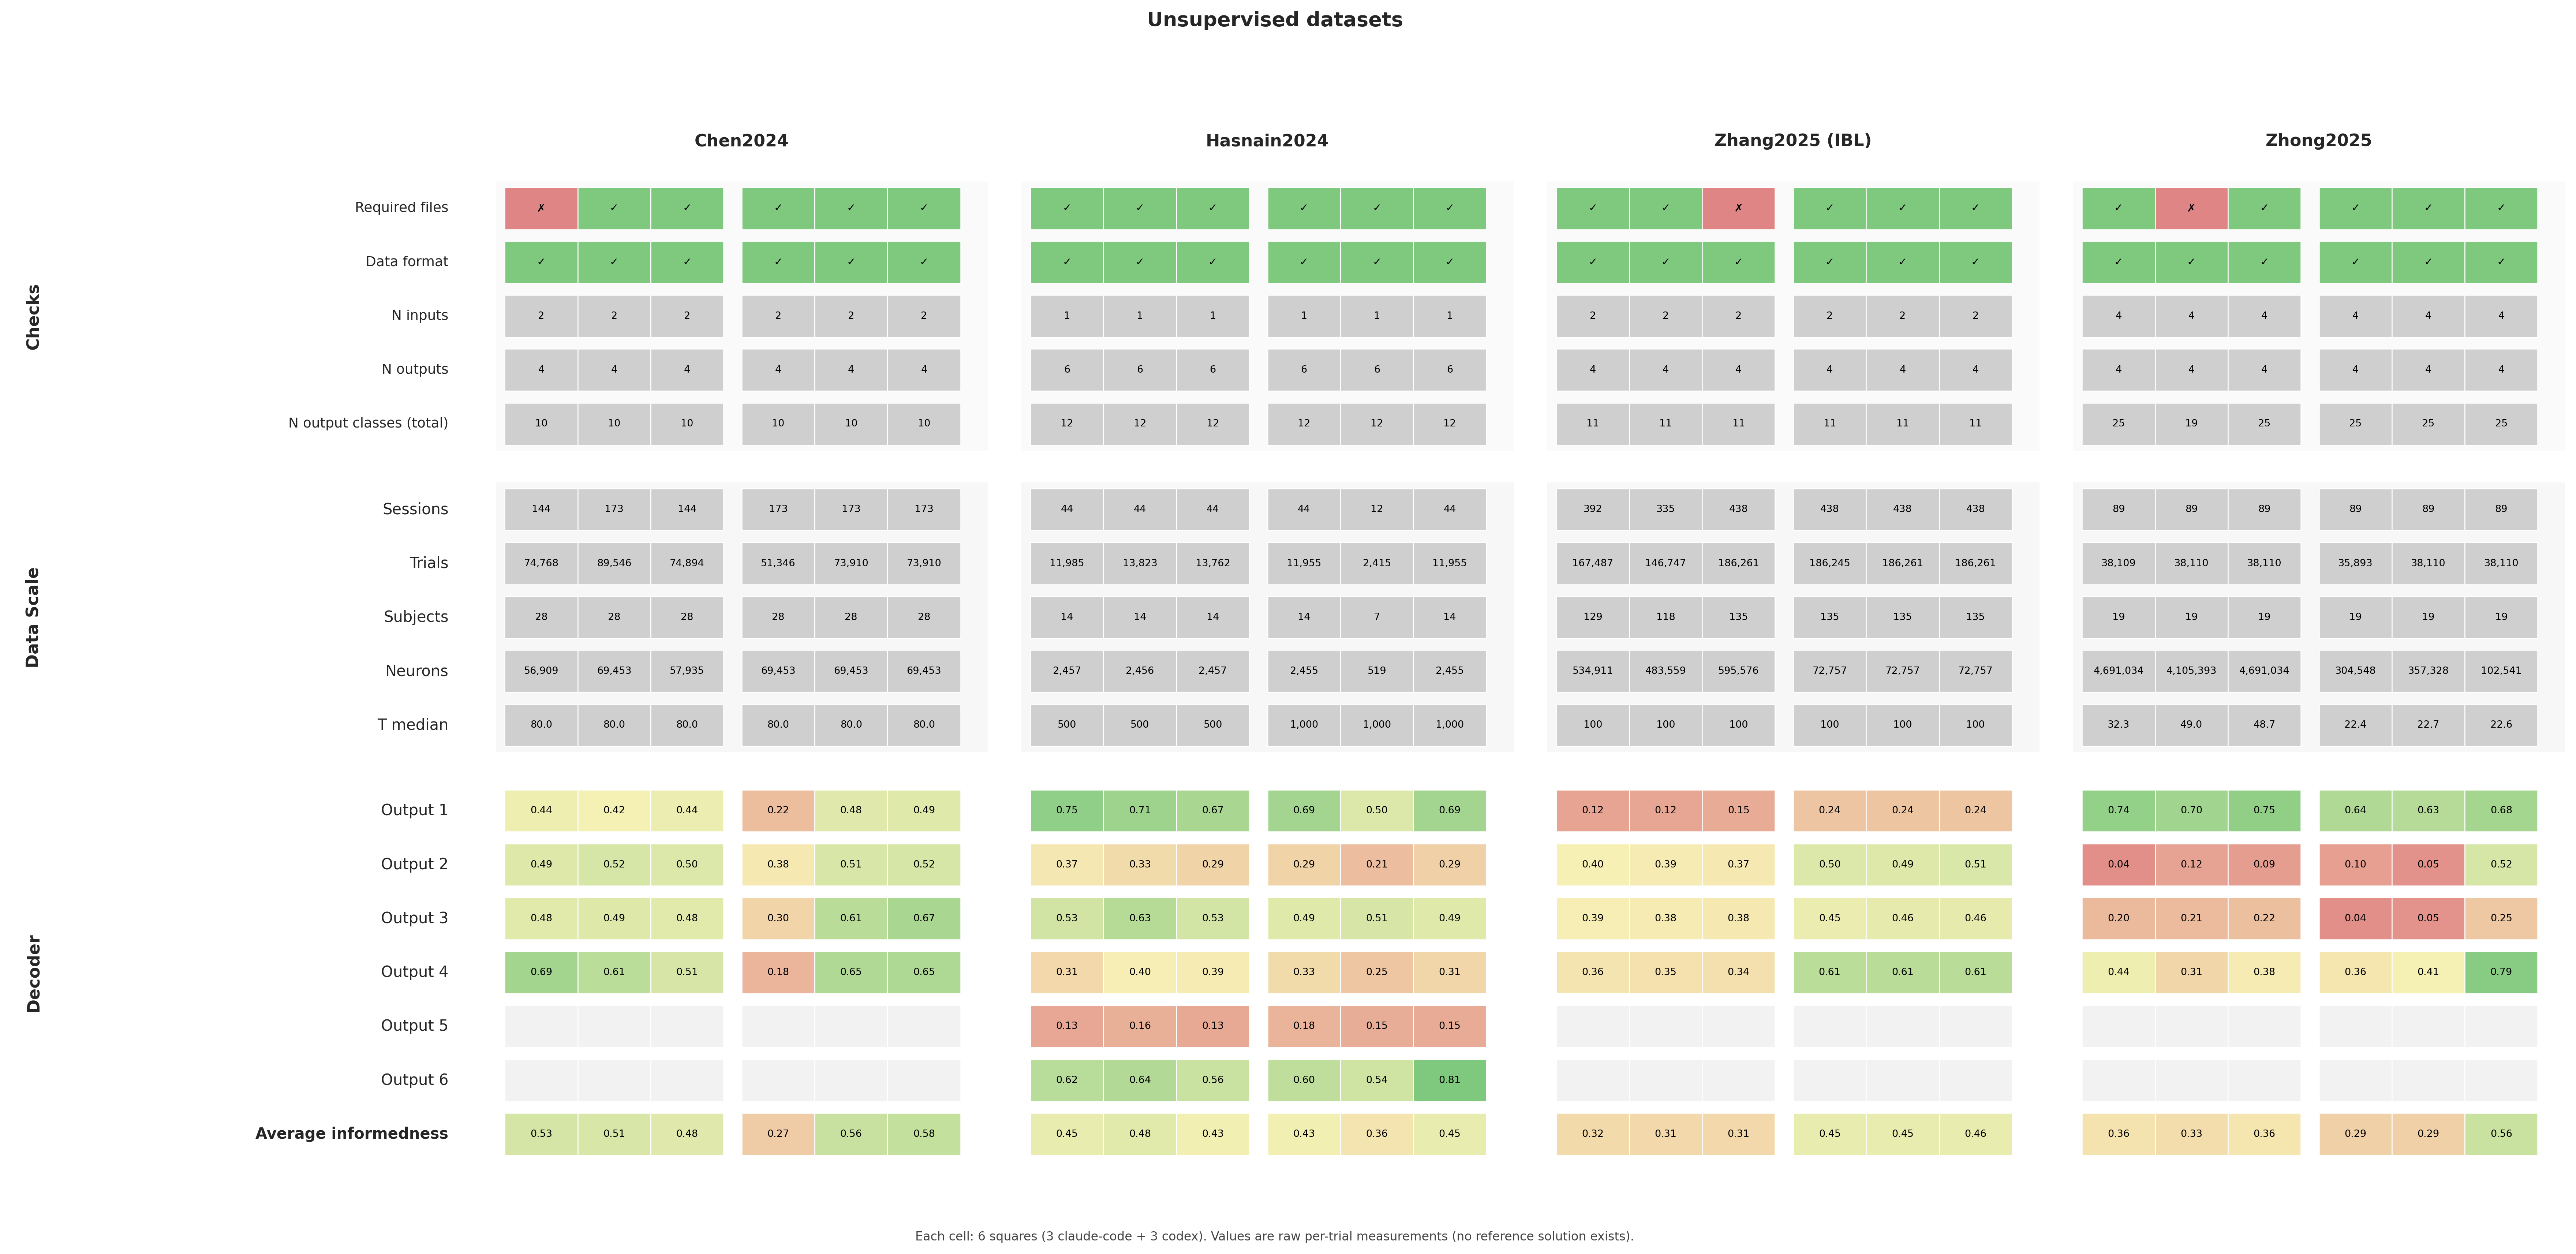

In [3]:
SCALE_FIELDS = [
    ("Sessions",  "nsessions"),
    ("Trials",    "ntrials_total"),
    ("Subjects",  "nsubjects"),
    ("Neurons",   "nneurons_total"),
    ("T median",  "T_median"),
]

#"check" rows (boolean pass/fail)


CHECK_FIELDS = [
    # (display label, fn(row: pd.Series) -> bool or None)
    ("Required files",          lambda r: _empty_list(r, "required_files_missing")
                                        and _empty_list(r, "required_files_empty")),
    #("Expected files",          lambda r: _eq(r, "expected_files_found", r.get("expected_files_total"))),
    ("Data format",             lambda r: _truthy(r, "full_data_format_valid")),
    # ("No contamination",        lambda r: not _truthy(r, "contamination_detected")),
    # The three below require a reference (NA for unsupervised tasks):
    ("Input variables match", lambda r: None if not _present(r, "input_range_mean_cost") else _below(r, "input_range_mean_cost", 1.0)),
    ("Output variables match", lambda r: _output_variables_match(r)),
    ("N output classes",     lambda r: _output_ranges_match(r)),
]




# For unsupervised figures the "Checks" section shows raw counts instead of
# match-against-reference bools. Each entry: (label, fn(row) -> number-or-bool-or-None, mode).
UNSUPERVISED_CHECK_FIELDS = [
    ("Required files",
        lambda r: _empty_list(r, "required_files_missing")
                  and _empty_list(r, "required_files_empty"),
        "bool"),
    ("Data format",
        lambda r: _truthy(r, "full_data_format_valid"),
        "bool"),
    ("N inputs",        lambda r: r.get("dinput"),  "int"),
    ("N outputs",       lambda r: r.get("doutput"), "int"),
    ("N output classes (total)",
        _total_n_output_classes, "int"),
]

def _decoder_var_rows(ds, supervised):
    """[(var_name, values, is_ratio), ...] for one dataset's decoder vars.

    Supervised: values are per-trial agent/reference accuracy ratios.
    Unsupervised: values are per-trial *informedness* — chance-baselined
    accuracy `(acc - chance) / (1 - chance)` where `chance = 1 / n_classes`
    (looked up per trial from `output_nclasses_<var>`). Falls back to raw
    accuracy when n_classes isn't recorded for a trial.
    """
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    if supervised:
        prefix     = "validation_balanced_accuracy_ratio."
        raw_prefix = "validation_balanced_accuracy."
    else:
        prefix     = "validation_balanced_accuracy."
        raw_prefix = None
    cols = sorted(c for c in sub.columns
                  if c.startswith(prefix) and not sub[c].isna().all())
    out = []
    for c in cols:
        var = c[len(prefix):]
        if supervised:
            ratio_col = c
            raw_col   = f"{raw_prefix}{var}"
            vals, is_r = _trial_values(ds, ratio_col, raw_col)
        else:
            #print('Computing informedness for variable', var)
            # Compute informedness per trial: (acc - chance) / (1 - chance)
            raw_col = c
            ncls_col = f"output_nclasses_{var}"
            vals = np.full(6, np.nan)
            for i, (_, row) in enumerate(sub.iterrows()):
                if i >= 6:
                    break
                acc = row.get(raw_col)
                if acc is None or (isinstance(acc, float) and np.isnan(acc)):
                    continue
                n = row.get(ncls_col)
                if (n is None or (isinstance(n, float) and np.isnan(n))
                        or n <= 1):
                    #print(f"  Trial {i}: n_classes not recorded or invalid ({n}), "
                    #      f"falling back to raw accuracy {acc:.3f}")
                    vals[i] = acc                       # fall back to raw
                else:
                    #print(f"  Trial {i}: n_classes={n}, chance={1/n:.3f}, acc={acc:.3f}")
                    chance = 1.0 / float(n)
                    if abs(1 - chance) < 1e-9:
                        vals[i] = acc
                    else:
                        vals[i] = (acc - chance) / (1 - chance)
            is_r = False
        out.append((var, vals, is_r))
    return out


def _decoder_avg_row(ds, supervised):
    """Per-trial mean of *chance-baselined* decoder accuracy across outputs.

    Each per-output accuracy is normalised as
        norm = (acc - chance) / (1 - chance)
    so outputs with different `n_classes` contribute on a common 0..1 scale.
    The chance level for each variable is derived from the per-variable
    `output_range_<var>` field (= n_classes - 1 for integer-coded categorical
    outputs), recorded by test_data_stats. For supervised cells the row
    shows `norm_agent_mean / norm_reference_mean` (ratio, RdYlGn-coloured);
    for unsupervised cells it shows the raw norm_agent_mean.

    If `output_range_<var>` isn't recorded for a variable (older trials), the
    raw accuracy is used in lieu of the normalised value for that output.
    """
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    raw_prefix = "validation_balanced_accuracy."
    raw_cols = [c for c in sub.columns
                if c.startswith(raw_prefix) and not sub[c].isna().all()
                and not c.startswith("validation_balanced_accuracy_")]
    if not raw_cols:
        return None

    def _chance(row, var, ref=False):
        col = f"output_nclasses_reference_{var}" if ref else f"output_nclasses_{var}"
        n = row.get(col)
        if n is None or (isinstance(n, float) and np.isnan(n)) or n <= 0:
            return None
        return 1.0 / float(n)

    def _norm(acc, chance):
        if chance is None or abs(1 - chance) < 1e-9:
            return acc          # fall back to raw if chance unknown
        return (acc - chance) / (1 - chance)

    out = np.full(6, np.nan)
    for i, (_, row) in enumerate(sub.iterrows()):
        if i >= 6:
            break
        agent_norms, ref_norms = [], []
        for raw_c in raw_cols:
            var = raw_c[len(raw_prefix):]
            agent_acc = row[raw_c]
            if not (isinstance(agent_acc, float) and np.isnan(agent_acc)):
                agent_norms.append(_norm(agent_acc, _chance(row, var, ref=False)))
            if supervised:
                ref_acc = row.get(f"validation_balanced_accuracy_reference.{var}", np.nan)
                if not (isinstance(ref_acc, float) and np.isnan(ref_acc)):
                    ref_norms.append(_norm(ref_acc, _chance(row, var, ref=True)))
        if not agent_norms:
            continue
        agent_mean = float(np.mean(agent_norms))
        if supervised and ref_norms:
            ref_mean = float(np.mean(ref_norms))
            out[i] = agent_mean / ref_mean if abs(ref_mean) > 1e-9 else np.nan
        else:
            out[i] = agent_mean
    return out


def _build_rows(datasets, supervised):
    """Build per-dataset rows for the figure.

    Decoder rows are padded so every dataset has the same number of
    per-output rows (= max across datasets). This keeps the "Average" row
    at a consistent vertical position across columns so a single set of
    row labels lines up correctly.
    """
    # Pre-fetch decoder rows + compute the max output count
    decoder_rows_by_ds = {ds: _decoder_var_rows(ds, supervised) for ds in datasets}
    n_outputs_max = max((len(d) for d in decoder_rows_by_ds.values()), default=0)
    # Supervised decoder cells are agent/reference *ratios* (centred at 1).
    # Unsupervised decoder cells are chance-baselined *informedness* values
    # in [0, 1] — coloured with a separate 0→1 ramp.
    dec_mode = "ratio" if supervised else "informedness"

    rows_per_ds = {}
    for ds in datasets:
        rs = []
        # Checks section first. Supervised: ✓/✗ bool match-vs-reference rows.
        # Unsupervised: raw counts (no reference exists).
        if supervised:
            for label, fn in CHECK_FIELDS:
                vals = _check_values(ds, fn)
                rs.append(("Checks", label, vals, "bool"))
        else:
            for label, fn, mode in UNSUPERVISED_CHECK_FIELDS:
                vals = _check_values(ds, fn) if mode == "bool" else _raw_values(ds, fn)
                rs.append(("Checks", label, vals, mode))
        for label, key in SCALE_FIELDS:
            ratio_col = f"{key}_ratio" if supervised else None
            vals, is_r = _trial_values(ds, ratio_col, key)
            if is_r:
                mode = "ratio"
            elif key == "T_median":
                mode = "raw"          # keep decimals (e.g. 32.3)
            else:
                mode = "int"          # counts: render as integers, no ".0"
            rs.append(("Data Scale", label, vals, mode))
        # Per-output rows (padded with NaN rows so Average lines up across DSs).
        d = decoder_rows_by_ds[ds]
        for idx in range(n_outputs_max):
            if idx < len(d):
                _var, vals, _is_r = d[idx]
                rs.append(("Decoder", f"Output {idx+1}", vals, dec_mode))
            else:
                rs.append(("Decoder", f"Output {idx+1}", np.full(6, np.nan), dec_mode))
        # Aggregate row: per-trial mean accuracy across outputs.
        avg = _decoder_avg_row(ds, supervised)
        if avg is None:
            avg = np.full(6, np.nan)
        rs.append(("Decoder", "Average", avg, dec_mode))
        rows_per_ds[ds] = rs
    return rows_per_ds


_cmap     = plt.get_cmap("RdYlGn")
_cnorm    = mcolors.TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)
NAN_GREY  = "#f2f2f2"
RAW_GREY  = "#cfcfcf"
PASS_GREEN = "#7fc97f"   # easier on the eye than full saturation
FAIL_RED   = "#e08585"
_cmap = mcolors.LinearSegmentedColormap.from_list(
    "LightRdYlGn", [FAIL_RED, "#f7f1b5", PASS_GREEN]
)
# Informedness colour scale: 0 = chance (red), 0.5 = halfway (yellow),
# 1 = perfect (green). Negative values (below chance) clamp to the red end.
_inorm = mcolors.Normalize(vmin=0.0, vmax=1.0, clip=True)


def render_metric_table(datasets, *, supervised, footnote, suptitle=None):
    """Build the metric-summary figure for one dataset family."""
    rows_per_ds    = _build_rows(datasets, supervised=supervised)
    # Informedness colour scale: span [0, max-observed-informedness] across
    # all unsupervised decoder cells in this figure. Falls back to vmax=1
    # when nothing is observed.
    if not supervised:
        inf_vals = [v for rows in rows_per_ds.values()
                      for (_sec, _lbl, vals, mode) in rows
                      if mode == "informedness"
                      for v in vals
                      if not np.isnan(v)]
        _inorm.vmax = max(max(inf_vals), 1e-6) if inf_vals else 1.0
    n_scale_rows   = len(SCALE_FIELDS)
    n_decoder_rows = max(sum(1 for r in rows if r[0] == "Decoder")
                         for rows in rows_per_ds.values())
    check_labels = ([(label, fn) for label, fn in CHECK_FIELDS] if supervised
                    else [(label, fn) for label, fn, _mode in UNSUPERVISED_CHECK_FIELDS])
    n_check_rows = len(check_labels)
    n_cols = len(datasets)

    square         = 0.85
    n_squares      = 6
    agent_gap      = 0.20
    cell_inner_pad = 0.05
    sq_w           = (square * 6 - agent_gap - 2 * cell_inner_pad) / n_squares
    sq_h           = square * 0.78
    section_gap    = 0.5
    title_pad      = 1.4

    y_top       = 0.0
    y_check_top = y_top
    y_check_bot = y_check_top - n_check_rows * square
    y_scale_top = y_check_bot - section_gap
    y_scale_bot = y_scale_top - n_scale_rows * square
    y_dec_top   = y_scale_bot - section_gap
    y_dec_bot   = y_dec_top - n_decoder_rows * square
    data_y_range = (y_top - y_dec_bot) + title_pad + 0.4
    data_x_range = square * 6 + 0.30

    left, right, top, bottom, wspace = 0.02, 0.99, 0.92, 0.05, 0.05
    label_w_ratio     = 0.9
    cell_aspect_fudge = 1.45

    fig_h_in = 0.55 * (n_check_rows + n_scale_rows + n_decoder_rows + 2) + 1.0
    axes_h_in = fig_h_in * (top - bottom)
    data_axes_w = axes_h_in / (data_y_range / data_x_range) * cell_aspect_fudge
    total_axes_w = (label_w_ratio + n_cols) * data_axes_w * (1 + wspace)
    fig_w_in = total_axes_w / (right - left)

    fig, axes = plt.subplots(
        1, n_cols + 1, figsize=(fig_w_in, fig_h_in), sharey=True,
        gridspec_kw={"width_ratios": [label_w_ratio] + [1.0] * n_cols},
    )
    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom, wspace=wspace)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=0.985)

    def _row_y(section, idx):
        if section == "Checks":
            return y_check_top - idx * square
        if section == "Data Scale":
            return y_scale_top - idx * square
        return y_dec_top - idx * square

    def _draw_cell(ax, x_left, y_top_cell, vals, mode):
        sq_y = y_top_cell - (square - sq_h) / 2 - sq_h
        x = x_left + cell_inner_pad
        for k, v in enumerate(vals):
            if k == 3:
                x += agent_gap
            if mode == "bool":
                if np.isnan(v):
                    face, glyph, txt_color = NAN_GREY, "", "#888"
                elif v >= 0.5:
                    face, glyph, txt_color = PASS_GREEN, "✓", "black"
                else:
                    face, glyph, txt_color = FAIL_RED, "✗", "black"
            elif mode == "ratio":
                face = mcolors.to_hex(_cmap(_cnorm(v))) if not np.isnan(v) else NAN_GREY
                glyph = "" if np.isnan(v) else f"{v:.2f}"
                txt_color = "#888" if np.isnan(v) else "black"
            elif mode == "informedness":
                face = mcolors.to_hex(_cmap(_inorm(v))) if not np.isnan(v) else NAN_GREY
                glyph = "" if np.isnan(v) else f"{v:.2f}"
                txt_color = "#888" if np.isnan(v) else "black"
            elif mode == "int":
                face = RAW_GREY if not np.isnan(v) else NAN_GREY
                glyph = "" if np.isnan(v) else f"{int(round(v)):,}"
                txt_color = "#888" if np.isnan(v) else "black"
            else:  # raw
                face = RAW_GREY if not np.isnan(v) else NAN_GREY
                glyph = _fmt(v, False) if not np.isnan(v) else ""
                txt_color = "#888" if np.isnan(v) else "black"
            ax.add_patch(_Rect((x, sq_y), sq_w, sq_h,
                                facecolor=face, edgecolor="white",
                                linewidth=0.6, zorder=1))
            if glyph:
                ax.text(x + sq_w / 2, sq_y + sq_h / 2, glyph,
                        ha="center", va="center",
                        fontsize=7 if mode == "bool" else 6.5,
                        color=txt_color, zorder=2)
            x += sq_w

    # --- Label axes ---
    ax_lbl = axes[0]
    ax_lbl.set_xlim(0, 1)
    ax_lbl.set_ylim(y_dec_bot - 0.4, y_top + title_pad)
    ax_lbl.set_axis_off()
    for sec_label, y_hi, y_lo in [
        ("Checks",     y_check_top, y_check_bot),    # ← NEW
        ("Data Scale", y_scale_top, y_scale_bot),
        ("Decoder",    y_dec_top,   y_dec_bot),
    ]:
        ax_lbl.text(0.05, (y_hi + y_lo) / 2, sec_label,
                    ha="center", va="center", fontsize=11,
                    fontweight="bold", rotation=90)
    for i, (label, _) in enumerate(check_labels):     # ← NEW
        y_mid = _row_y("Checks", i) - square / 2
        ax_lbl.text(0.97, y_mid, label, ha="right", va="center", fontsize=9)
    for i, (label, _) in enumerate(SCALE_FIELDS):
        y_mid = _row_y("Data Scale", i) - square / 2
        ax_lbl.text(0.97, y_mid, label, ha="right", va="center", fontsize=10)
    # Decoder section: per-row labels are "Output 1" ... "Output N" then
    # "Average" (last row). N is the max number of outputs across datasets
    # (n_decoder_rows includes the trailing Average row, so N = n_decoder_rows - 1).
    n_output_rows = n_decoder_rows - 1
    for i in range(n_output_rows):
        y_mid = _row_y("Decoder", i) - square / 2
        ax_lbl.text(0.97, y_mid, f"Output {i+1}", ha="right", va="center", fontsize=10)
    y_mid = _row_y("Decoder", n_output_rows) - square / 2
    ax_lbl.text(0.97, y_mid, "Average informedness", ha="right", va="center",
                fontsize=10, fontweight="bold")
    # --- Per-dataset axes ---
    for j, ds in enumerate(datasets):
        ax = axes[j + 1]
        ax.add_patch(_Rect((0, y_scale_bot),
                           data_x_range, y_scale_top - y_scale_bot,
                           facecolor="#f7f7f7", edgecolor="none", zorder=-1))
        ax.add_patch(_Rect((0, y_check_bot),
                            data_x_range, y_check_top - y_check_bot,
                            facecolor="#fafafa", edgecolor="none", zorder=-1))
        check_idx = scale_idx = decoder_idx = 0
        for section, label, vals, mode in rows_per_ds[ds]:
            if section == "Checks":
                y_top_cell = _row_y("Checks", check_idx)
                check_idx += 1
            elif section == "Data Scale":
                y_top_cell = _row_y("Data Scale", scale_idx)
                scale_idx += 1
            else:
                y_top_cell = _row_y("Decoder", decoder_idx)
                decoder_idx += 1
            _draw_cell(ax, 0.05, y_top_cell, vals, mode)
        ax.set_xlim(-0.1, data_x_range)
        ax.set_ylim(y_dec_bot - 0.4, y_top + title_pad)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.text(data_x_range / 2, y_top + 0.5, display_name(ds),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

    fig.text(0.5, 0.005, footnote,
             ha="center", va="bottom", fontsize=8, color="#444")
    plt.show()


render_metric_table(
    SUPERVISED_DS, supervised=True,
    suptitle="Supervised datasets",
    footnote="Each cell: 6 squares (3 claude-code + 3 codex). Cell colour "
             "(RdYlGn centred at 1.0) = per-trial agent / reference ratio.",
)

render_metric_table(
    UNSUPERVISED_DS, supervised=False,
    suptitle="Unsupervised datasets",
    footnote="Each cell: 6 squares (3 claude-code + 3 codex). Values are "
             "raw per-trial measurements (no reference solution exists).",
)

### Decoder accuracy LaTeX tables

Two tables (supervised + unsupervised) showing the per-trial decoder values. Rows = (Dataset, Variable). Columns = the 3 claude-code trials and the 3 codex trials. Numbers match exactly what's plotted above; the table makes them easier to read off and copy into the paper. For supervised datasets the values are agent/reference ratios; for unsupervised they're raw validation balanced accuracy.

In [4]:
# LaTeX tables — one per dataset family. Reuses _decoder_var_rows from
# the plotting cell above so naming / ordering / alias normalisation is
# identical between the figure and the table. The supervised table also
# shows a Reference column with the manual-solution absolute balanced
# accuracy followed by the chance level (1/n_classes) in parens, and
# colours the per-trial ratios by deviation from 1.0:
#   ratio > 1.10           → blue
#   0.90 <= ratio <= 1.10  → black (default)
#   0.70 <= ratio <  0.90  → orange
#   ratio <  0.70          → red

# Per-(dataset, variable) chance level, extracted from the "Accuracy vs
# Chance" tables that the agents wrote into
# `harbor-jobs/<ds>/<agent>/<trial>/verifier/snapshot/CONVERSION_NOTES.md`.
# Where multiple trials reported different values for the same variable
# (because agents picked different binnings) we use the modal value across
# the 9-ish reporting trials. See `harbor-jobs/.../CONVERSION_NOTES.md`
# under the "Check 1: Accuracy vs Chance" section for the originals.
# Variable names here are the *ratio* (canonical) names — for sosa2024
# `position` is the same conceptual variable as `absolute_position` in the
# notes, and `reward_location` is `reward_zone_location`.
CHANCE_LEVELS = {
    # Supervised
    "allen2p": {
        "image_change":   0.500,    # binary
        "image_name":     0.0625,   # 1/16 — modal across agents (some used 1/8 or 1/17)
        "pupil_diameter": 0.200,    # 5-class
        "running_speed":  0.200,    # 5-class
        "trial_outcome":  0.250,    # 4-class
    },
    "lee2025":    {"position":      0.1111},  # 1/9
    "majnik2025": {"motion_energy": 0.200},   # 5-class
    "sosa2024": {
        "position":                0.200,     # = absolute_position in notes
        "speed":                   0.200,
        "lick":                    0.500,
        "distance_to_reward_zone": 0.1429,    # 1/7
        "reward_location":         0.3333,    # = reward_zone_location in notes
        "reward_outcome":          0.500,
    },
    # Unsupervised — same source. Keys are the canonical (alias-applied)
    # variable names that show up as rows in the unsupervised table.
    "chen2024": {
        "choice":     0.500,    # binary
        "early_lick": 0.500,    # binary
        "outcome":    0.3333,   # 1/3
        "tongue_y":   0.3333,   # 1/3 (was tongue_y_position in notes)
    },
    "hasnain2024": {
        "context":         0.500,   # binary (was behavioral_context in notes)
        "lick_direction":  0.500,   # binary
        "motion_energy":   0.500,   # binary
        "outcome":         0.500,   # binary
        "paw_velocity":    0.500,   # binary
        "tongue_velocity": 0.500,   # binary
    },
    "zhang2025": {
        "choice":                0.500,   # binary
        "prior":                 0.3333,  # 1/3 (was prior_probability_left/_of_left in notes)
        "wheel_speed":           0.3333,
        "whisker_motion_energy": 0.3333,
    },
    "zhong2025": {
        "licking":         0.500,   # binary
        "position":        0.250,   # 4-class (modal — one agent used 5-class)
        "running_speed":   0.250,   # 4-class
        "visual_stimulus": 0.0667,  # 1/15 — modal; some agents used 4-class or binary
    },
}

# Per-dataset row order overrides for the supervised table. Variables not
# listed here keep the alphabetical default from _decoder_var_rows.
ROW_ORDER = {
    "allen2p":  ["trial_outcome", "running_speed", "pupil_diameter",
                 "image_name", "image_change"],
    "sosa2024": ["position", "speed", "lick", "distance_to_reward_zone",
                 "reward_location", "reward_outcome"],
    # Unsupervised orderings.
    "chen2024":    ["choice", "outcome", "early_lick", "tongue_y"],
    "hasnain2024": ["context", "outcome", "lick_direction",
                    "tongue_velocity", "paw_velocity", "motion_energy"],
    "zhang2025":   ["prior", "choice", "wheel_speed", "whisker_motion_energy"],
    # zhong2025: alphabetical default (licking, position, running_speed, visual_stimulus)
}


def _ordered_decoder_rows(ds, supervised):
    """`_decoder_var_rows` reordered per ROW_ORDER if listed."""
    rows = _decoder_var_rows(ds, supervised)
    desired = ROW_ORDER.get(ds)
    if not desired:
        return rows
    by_var = {r[0]: r for r in rows}
    out = [by_var[v] for v in desired if v in by_var]
    out += [r for r in rows if r[0] not in set(desired)]
    return out


def _ratio_color(v):
    if np.isnan(v):
        return None
    if v > 1.10: return "blue"
    if v < 0.70: return "red"
    if v < 0.90: return "orange"
    return None


def _fmt_ratio(v):
    if np.isnan(v):
        return "--"
    s = f"{v:.3f}"
    color = _ratio_color(v)
    return r"\textcolor{" + color + r"}{" + s + r"}" if color else s


def _informedness_color(v):
    """Thresholds for informedness in [0, 1] (chance=0, perfect=1)."""
    if np.isnan(v):
        return None
    if v >= 0.50: return "blue"      # well above chance
    if v <  0.10: return "red"       # essentially chance
    if v <  0.25: return "orange"    # weakly above chance
    return None                      # 0.25--0.50: neutral


def _fmt_informedness(v):
    if np.isnan(v):
        return "--"
    s = f"{v:.3f}"
    color = _informedness_color(v)
    return r"\textcolor{" + color + r"}{" + s + r"}" if color else s


def _ref_value(ds, var):
    """Reference (manual-solution) absolute balanced accuracy for this var."""
    col = f"validation_balanced_accuracy_reference.{var}"
    sub = mdf[mdf.dataset == ds]
    if col not in sub.columns or sub[col].isna().all():
        return float("nan")
    return float(sub[col].dropna().iloc[0])


def _fmt_chance(c):
    """Chance level rendered to 3 decimal places."""
    return f"{c:.3f}"


def _latex_supervised_table(datasets, *, label, caption):
    """Per-trial decoder ratios + per-dataset Average row.

    Per-output cells mirror the figure's supervised Decoder rows:
    agent / reference accuracy ratio.  The trailing per-dataset Average row
    mirrors the figure's Decoder "Average" row: ratio of chance-baselined
    means (agent informedness mean / reference informedness mean).
    """
    lines = [
        r"% requires \usepackage{booktabs, multirow, xcolor}",
        r"\begin{table}[t]",
        r"\centering",
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{l l rrr rrr c}",
        r"\toprule",
        (r" & & \multicolumn{3}{c}{Claude Code} "
         r"& \multicolumn{3}{c}{Codex} & Reference \\"),
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}",
        r"Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 & (chance) \\",
        r"\midrule",
    ]
    for di, ds in enumerate(datasets):
        rows = _ordered_decoder_rows(ds, supervised=True)
        if not rows:
            continue
        n = len(rows)
        for ri, (var, vals, _is_ratio) in enumerate(rows):
            ds_cell = (r"\multirow{" + str(n) + r"}{*}{"
                       + display_name(ds) + r"}") if ri == 0 else ""
            var_cell = var.replace("_", r"\_")
            ratio_cells = [_fmt_ratio(v) for v in vals]
            ref = _ref_value(ds, var)
            chance = CHANCE_LEVELS.get(ds, {}).get(var)
            if np.isnan(ref):
                ref_cell = "--"
            elif chance is None:
                ref_cell = f"{ref:.3f}"
            else:
                ref_cell = f"{ref:.3f} ({_fmt_chance(chance)})"
            lines.append(" & ".join([ds_cell, var_cell, *ratio_cells, ref_cell])
                         + r" \\")
        if di < len(datasets) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        r"\label{" + label + r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


def _latex_unsupervised_table(datasets, *, label, caption):
    """Per-trial informedness, one row per decoded output variable.

    Per-output cells mirror the figure's unsupervised Decoder rows:
    informedness = (acc - chance) / (1 - chance), with chance = 1 / n_classes
    per trial.
    """
    lines = [
        r"% requires \usepackage{booktabs, multirow, xcolor}",
        r"\begin{table}[t]",
        r"\centering",
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{l l rrr rrr}",
        r"\toprule",
        (r" & & \multicolumn{3}{c}{Claude Code} "
         r"& \multicolumn{3}{c}{Codex} \\"),
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}",
        r"Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 \\",
        r"\midrule",
    ]
    for di, ds in enumerate(datasets):
        rows = _ordered_decoder_rows(ds, supervised=False)
        if not rows:
            continue
        n = len(rows)
        for ri, (var, vals, _is_ratio) in enumerate(rows):
            ds_cell = (r"\multirow{" + str(n) + r"}{*}{"
                       + display_name(ds) + r"}") if ri == 0 else ""
            var_cell = var.replace("_", r"\_")
            # vals are informedness values in [0, 1] (chance=0, perfect=1).
            cells = [_fmt_informedness(v) for v in vals]
            lines.append(" & ".join([ds_cell, var_cell, *cells]) + r" \\")
        if di < len(datasets) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        r"\label{" + label + r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


_emit_latex(_latex_supervised_table(
    SUPERVISED_DS,
    label="tab:decoder-supervised",
    caption=("Per-trial decoder performance, supervised datasets. The "
             "first six numeric columns are the agent / reference ratio "
             "of validation balanced accuracy (T1--T3 of each agent). "
             "Colour: \\textcolor{blue}{blue} if ratio $>$ 1.10, "
             "\\textcolor{orange}{orange} if 0.70 $\\leq$ ratio $<$ 0.90, "
             "\\textcolor{red}{red} if ratio $<$ 0.70. The Reference column "
             "shows the manual-solution absolute balanced accuracy with the "
             "chance level $1/n_{classes}$ in parentheses."),
), "decoder_supervised.tex")

print()
_emit_latex(_latex_unsupervised_table(
    UNSUPERVISED_DS,
    label="tab:decoder-unsupervised",
    caption=("Per-trial decoder performance, unsupervised datasets. "
             "Per-output cells report the chance-baselined informedness "
             "$(\\mathrm{acc}-\\mathrm{chance})/(1-\\mathrm{chance})$, with "
             "$\\mathrm{chance}=1/n_\\mathrm{classes}$ computed per trial. "
             "Informedness is bounded by 1 (perfect); 0 corresponds to "
             "chance and negative values to below-chance performance. "
             "Colour: \\textcolor{blue}{blue} if informedness $\\geq$ 0.50, "
             "\\textcolor{orange}{orange} if 0.10 $\\leq$ informedness $<$ "
             "0.25, \\textcolor{red}{red} if informedness $<$ 0.10."),
), "decoder_unsupervised.tex")

% requires \usepackage{booktabs, multirow, xcolor}
\begin{table}[t]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code} & \multicolumn{3}{c}{Codex} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 & (chance) \\
\midrule
\multirow{6}{*}{Allen2P} & trial\_outcome & 0.919 & 0.991 & \textcolor{orange}{0.838} & 0.905 & \textcolor{orange}{0.836} & \textcolor{orange}{0.840} & 0.319 (0.250) \\
 & running\_speed & \textcolor{orange}{0.820} & \textcolor{blue}{1.230} & \textcolor{orange}{0.703} & \textcolor{orange}{0.774} & \textcolor{red}{0.699} & \textcolor{red}{0.698} & 0.350 (0.200) \\
 & pupil\_diameter & \textcolor{red}{0.659} & \textcolor{blue}{1.101} & \textcolor{red}{0.628} & \textcolor{orange}{0.734} & \textcolor{red}{0.629} & \textcolor{red}{0.628} & 0.432 (0.200) \\
 & image\_name & 0.974 & \textcolor{blue}{1.146} & \textcolor{red}{0.372} & \textcolor{red}{0.634} & \tex

### Checks LaTeX tables

One row per check, per dataset. Supervised checks are bool pass/fail vs the reference (✓/✗/--). Unsupervised checks mix bool (Required files, Data format) with integer counts (N inputs, N outputs, N output classes total).

In [ ]:
def _fmt_check_bool(v):
    """LaTeX cell for a 0/1/NaN bool from `_check_values`."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "--"
    return (r"\textcolor{green!55!black}{\checkmark}" if v >= 0.5
            else r"\textcolor{red!70!black}{$\times$}")


def _fmt_check_int(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "--"
    return f"{int(round(v)):,}"


def _latex_checks_table(datasets, *, supervised, label, caption):
    if supervised:
        rows_spec = [(lbl, fn, "bool") for lbl, fn in CHECK_FIELDS]
    else:
        rows_spec = list(UNSUPERVISED_CHECK_FIELDS)
    lines = [
        r"% requires \usepackage{booktabs, multirow, xcolor, amssymb}",
        r"\begin{table}[t]",
        r"\centering",
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{l l rrr rrr}",
        r"\toprule",
        (r" & & \multicolumn{3}{c}{Claude Code} "
         r"& \multicolumn{3}{c}{Codex} \\"),
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}",
        r"Dataset & Check & T1 & T2 & T3 & T1 & T2 & T3 \\",
        r"\midrule",
    ]
    for di, ds in enumerate(datasets):
        n = len(rows_spec)
        for ri, (rlbl, fn, mode) in enumerate(rows_spec):
            ds_cell = (r"\multirow{" + str(n) + r"}{*}{"
                       + display_name(ds) + r"}") if ri == 0 else ""
            if mode == "bool":
                vals = _check_values(ds, fn)
                cells = [_fmt_check_bool(v) for v in vals]
            else:
                vals = _raw_values(ds, fn)
                cells = [_fmt_check_int(v) for v in vals]
            lines.append(" & ".join([ds_cell, rlbl, *cells]) + r" \\")
        if di < len(datasets) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        r"\label{" + label + r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


_emit_latex(_latex_checks_table(
    SUPERVISED_DS, supervised=True,
    label="tab:checks-supervised",
    caption=("Verifier checks, supervised datasets. Each cell is \\checkmark "
             "(pass) or $\\times$ (fail) for that trial."
             " `Required files': are all required files present; `Data format': is the output data file format correct;"
             " `Input variables match': One-to-one matching between agent and reference input variables found; "
             " `Output variables match': One-to-one matching between agent and reference output variables found; "
             " `N output classes': Number of output classes match between agent and reference for each output variable."
             " For Majnik2025, input variable mismatch occurred because reference solution used minutes unit while some agents used seconds. "),
), "checks_supervised.tex")

print()
_emit_latex(_latex_checks_table(
    UNSUPERVISED_DS, supervised=False,
    label="tab:checks-unsupervised",
    caption=("Verifier checks and input/output sizes. "
             "`Required files' and `Data format' indicate whether all required files are present and output data file format is correct."
            " `N inputs': number of input variables, `N outputs': number of output variables, N output classes (total): total number of unique classes across all decoded variables."
            " For supervised tasks, these numbers are compared to reference solution. For these unsupervised tasks, there is no reference solution, and we can examine variability across trials. "
            ),
), "checks_unsupervised.tex")

### Data Scale LaTeX tables

Same layout as the decoder-accuracy tables but for the dataset-scale metrics (Sessions, Trials, Subjects, Neurons, T median). Supervised: agent / reference ratios. Unsupervised: per-trial values as ratios to the row mean (no reference exists), with the row mean in the Average column.

In [4]:
# LaTeX tables — Data Scale (Sessions / Trials / Subjects / Neurons /
# T_median). Same layout and colour scheme as the decoder accuracy tables —
# one table per dataset family, (dataset × metric) per row.
#   * Supervised: each cell is the per-trial agent / reference ratio of the
#     scale metric. The Reference column shows the absolute reference value
#     where it can be derived (raw / ratio); for datasets that store only
#     ratios in the verifier output, the cell is "--".
#   * Unsupervised: no reference exists, so the per-trial cells are the
#     ratio of each trial's raw value to the row mean (matches the
#     unsupervised decoder table). The Average column shows the row mean.

SCALE_FIELDS_LATEX = [
    ("Sessions", "nsessions"),
    ("Trials",   "ntrials_total"),
    ("Subjects", "nsubjects"),
    ("Neurons",  "nneurons_total"),
    ("T median", "T_median"),
]

# Reference (manual-solution) scale stats per supervised dataset.
# Sources:
#   lee2025 / majnik2025 / sosa2024 — from harbor-jobs/<ds>/oracle/.../verifier/
#                                     snapshot/stats_full.json (data_summary
#                                     block; nneurons_total = sum of
#                                     brain_region_neuron_counts).
#   allen2p — no oracle folder; derived from raw / ratio in any agent trial.
REFERENCE_SCALE = {
    "allen2p":    {"nsessions": 236, "ntrials_total": 71242, "nsubjects": 37,
                   "nneurons_total": 41390, "T_median": 265.2},
    "lee2025":    {"nsessions": 207, "ntrials_total":  8187, "nsubjects":  7,
                   "nneurons_total": 69744, "T_median": 1800.0},
    "majnik2025": {"nsessions":  41, "ntrials_total":  1090, "nsubjects":  6,
                   "nneurons_total": 20445, "T_median": 1800.0},
    "sosa2024":   {"nsessions": 152, "ntrials_total": 12216, "nsubjects": 11,
                   "nneurons_total": 138678, "T_median": 197.5},
}


def _fmt_scale_abs(v, key):
    """Format an absolute scale value. T median: 1dp. Other counts: comma
    format. Exception: nneurons_total uses compact K notation when >= 100K
    (e.g. 305K, 2375K). No M-suffix — even millions are kept in K so the
    reader doesn't have to mentally switch units across rows."""
    if v is None or np.isnan(v):
        return "--"
    if key == "T_median":
        return f"{v:.1f}"
    if key == "nneurons_total" and v >= 100_000:
        return f"{v / 1_000:,.0f}K"
    return f"{v:,.0f}"


def _scale_supervised_row(ds, key):
    """(ratios_6, reference_value) for one (dataset, metric)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    ratio_col = f"{key}_ratio"
    if ratio_col not in sub.columns or sub[ratio_col].isna().all():
        return np.full(6, np.nan), float("nan")
    ratios = sub[ratio_col].values.astype(float)
    ref = REFERENCE_SCALE.get(ds, {}).get(key, float("nan"))
    return ratios, ref


def _scale_unsupervised_row(ds, key):
    """(per-trial RAW values, row mean) for one (dataset, metric).
    Matches the figure, which shows raw scale values for unsupervised tasks
    (not ratios-to-row-mean as a previous version of this LaTeX did)."""
    sub = mdf[mdf.dataset == ds].sort_values(["agent", "trial"])
    if key not in sub.columns or sub[key].isna().all():
        return np.full(6, np.nan), float("nan")
    raws = sub[key].values.astype(float)
    mean = float(np.nanmean(raws)) if not np.all(np.isnan(raws)) else float("nan")
    return raws, mean


def _latex_scale_table(datasets, *, supervised, label, caption):
    last_col = "Reference" if supervised else "Average"
    lines = [
        r"% requires \usepackage{booktabs, multirow, xcolor}",
        r"\begin{table}[t]",
        r"\centering",
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{l l rrr rrr c}",
        r"\toprule",
        (r" & & \multicolumn{3}{c}{Claude Code} "
         r"& \multicolumn{3}{c}{Codex} & " + last_col + r" \\"),
        r"\cmidrule(lr){3-5} \cmidrule(lr){6-8}",
        r"Dataset & Metric & T1 & T2 & T3 & T1 & T2 & T3 & \\",
        r"\midrule",
    ]
    for di, ds in enumerate(datasets):
        n = len(SCALE_FIELDS_LATEX)
        for ri, (mlabel, key) in enumerate(SCALE_FIELDS_LATEX):
            ds_cell = (r"\multirow{" + str(n) + r"}{*}{"
                       + display_name(ds) + r"}") if ri == 0 else ""
            if supervised:
                ratios, ref = _scale_supervised_row(ds, key)
                cells = [_fmt_ratio(v) for v in ratios]
            else:
                raws, ref = _scale_unsupervised_row(ds, key)
                # Match the figure: raw absolute values per trial, no colour.
                cells = [_fmt_scale_abs(v, key) for v in raws]
            ref_cell = _fmt_scale_abs(ref, key)
            lines.append(" & ".join([ds_cell, mlabel, *cells, ref_cell])
                         + r" \\")
        if di < len(datasets) - 1:
            lines.append(r"\midrule")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\caption{" + caption + r"}",
        r"\label{" + label + r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


_emit_latex(_latex_scale_table(
    SUPERVISED_DS, supervised=True,
    label="tab:scale-supervised",
    caption=("Dataset-scale statistics, supervised datasets. Each cell "
             "is the agent / reference ratio of the scale metric (T1--T3 of "
             "each agent). Colour key matches "
             "Table~\\ref{tab:decoder-supervised}: \\textcolor{blue}{blue} "
             "if ratio $>$ 1.10, \\textcolor{orange}{orange} if 0.70 "
             "$\\leq$ ratio $<$ 0.90, \\textcolor{red}{red} if ratio $<$ "
             "0.70. The Reference column shows the absolute manual-solution "
             "value."),
), "scale_supervised.tex")

print()
_emit_latex(_latex_scale_table(
    UNSUPERVISED_DS, supervised=False,
    label="tab:scale-unsupervised",
    caption=("Dataset-scale statistics, unsupervised datasets. No reference "
             "manual solution exists for these datasets, so each cell shows "
             "the absolute raw value reported by that trial (T1--T3 of each "
             "agent). The Average column shows the mean across the 6 trial "
             "runs."),
), "scale_unsupervised.tex")

% requires \usepackage{booktabs, multirow, xcolor}
\begin{table}[t]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code} & \multicolumn{3}{c}{Codex} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Metric & T1 & T2 & T3 & T1 & T2 & T3 & \\
\midrule
\multirow{5}{*}{Allen2P} & Sessions & \textcolor{orange}{0.856} & \textcolor{orange}{0.856} & \textcolor{orange}{0.856} & \textcolor{blue}{1.191} & \textcolor{orange}{0.843} & \textcolor{orange}{0.843} & 236 \\
 & Trials & \textcolor{orange}{0.730} & \textcolor{orange}{0.730} & \textcolor{orange}{0.730} & \textcolor{blue}{1.183} & \textcolor{orange}{0.717} & \textcolor{orange}{0.717} & 71,242 \\
 & Subjects & 1.027 & 1.027 & 1.027 & 1.027 & 1.027 & 1.027 & 37 \\
 & Neurons & \textcolor{orange}{0.711} & \textcolor{orange}{0.711} & \textcolor{orange}{0.711} & 1.012 & \textcolor{orange}{0.705} & \textcolor{orange}{0.705} & 41,390 \\
 & T median & 0.990 & \textcolor{red